In [70]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [71]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_filename = self.image_files[idx]
        # image files are named case_*, matching mask files named seg_*
        mask_filename = image_filename.replace('case_', 'seg_')

        image = Image.open(os.path.join(self.image_dir, image_filename)).convert('L')
        if self.transform:
            image = self.transform(image)

        mask = Image.open(os.path.join(self.mask_dir, mask_filename)).convert('L')

        # Resize with nearest-neighbor interpolation specifically - the
        # raw values are discrete class labels, not real pixel
        # intensities, so bilinear/default interpolation would blend
        # adjacent labels together and invent in-between values that
        # don't correspond to any real class.
        mask = mask.resize((128, 128), Image.NEAREST)

        # Raw mask values are {0, 85, 170, 255}, encoding class indices
        # {0, 1, 2, 3} as (class_index * 85). Divide by 85 and round to
        # recover the class index, then cast to a LongTensor of class
        # indices (shape [128, 128]) - not one-hot, since CrossEntropyLoss
        # (and similar loss functions) expect class indices directly.
        mask = np.array(mask)
        mask = torch.from_numpy(mask / 85.0).round().long()

        return image, mask

In [72]:
data_root = "keras_png_slices_data/keras_png_slices_data"

image_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_seg_dataset = SegmentationDataset(
    os.path.join(data_root, "keras_png_slices_train"),
    os.path.join(data_root, "keras_png_slices_seg_train"),
    transform=image_transform,
)
test_seg_dataset = SegmentationDataset(
    os.path.join(data_root, "keras_png_slices_test"),
    os.path.join(data_root, "keras_png_slices_seg_test"),
    transform=image_transform,
)
validate_seg_dataset = SegmentationDataset(
    os.path.join(data_root, "keras_png_slices_validate"),
    os.path.join(data_root, "keras_png_slices_seg_validate"),
    transform=image_transform,
)

print(f"Train: {len(train_seg_dataset)}, Test: {len(test_seg_dataset)}, Validate: {len(validate_seg_dataset)}")

Train: 9664, Test: 544, Validate: 1120


In [73]:
# Inspect the raw label values in one training mask before deciding how
# to handle them (resize strategy, one-hot encoding, number of classes).
image, mask = train_seg_dataset[0]

mask_np = mask.numpy()
unique_values = np.unique(mask_np)

print("Unique mask values:", unique_values)
print("Number of unique values:", len(unique_values))

Unique mask values: [0 1 2 3]
Number of unique values: 4


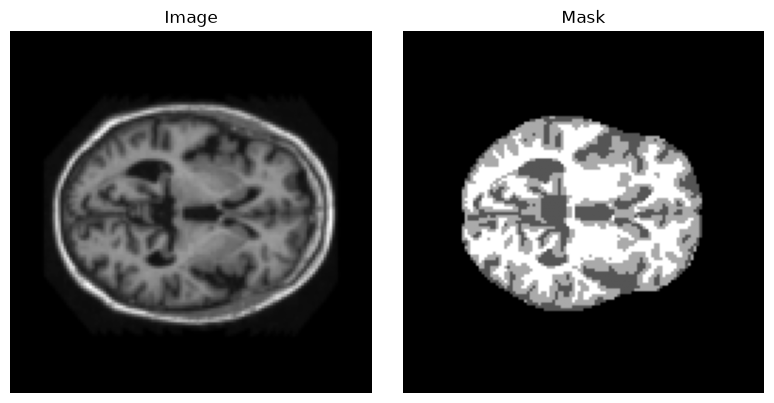

In [74]:
# Show the image and its matching mask side by side to confirm they
# correspond to the same slice.
image, mask = train_seg_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].set_title("Image")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [75]:
# DataLoaders for the segmentation datasets (same setup as the VAE notebook).
BATCH_SIZE = 64

train_seg_loader = DataLoader(train_seg_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_seg_loader = DataLoader(test_seg_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
validate_seg_loader = DataLoader(validate_seg_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Sanity check: pull one batch and confirm the mask only contains class
# indices {0, 1, 2, 3} - not the raw {0, 85, 170, 255} values or anything
# invented by interpolation.
image_batch, mask_batch = next(iter(train_seg_loader))

print("Image batch shape:", image_batch.shape)
print("Mask batch shape:", mask_batch.shape)
print("Unique mask values in batch:", torch.unique(mask_batch))

Image batch shape: torch.Size([64, 1, 128, 128])
Mask batch shape: torch.Size([64, 128, 128])
Unique mask values in batch: tensor([0, 1, 2, 3])


In [76]:
class UNetEncoder(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()

        # Each block is a "double conv": Conv2d -> ReLU -> Conv2d -> ReLU
        # (standard U-Net practice - two convs per block, not one).
        # kernel_size=3, padding=1 keeps the spatial size unchanged within
        # a block; only the MaxPool2d(2) after each block halves the
        # resolution (unlike the VAE encoder, where the conv stride itself
        # did the downsampling).
        self.block1 = self._double_conv(in_channels, 64)   # 1   -> 64
        self.block2 = self._double_conv(64, 128)            # 64  -> 128
        self.block3 = self._double_conv(128, 256)           # 128 -> 256
        self.block4 = self._double_conv(256, 512)           # 256 -> 512

        self.pool = nn.MaxPool2d(2)

    def _double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Save the feature map from BEFORE each pooling step - these are
        # exactly what the decoder will need later for skip connections.
        skip_connections = []

        x1 = self.block1(x)          # 128x128, 64 channels
        skip_connections.append(x1)
        x = self.pool(x1)            # -> 64x64

        x2 = self.block2(x)          # 64x64, 128 channels
        skip_connections.append(x2)
        x = self.pool(x2)            # -> 32x32

        x3 = self.block3(x)          # 32x32, 256 channels
        skip_connections.append(x3)
        x = self.pool(x3)            # -> 16x16

        x4 = self.block4(x)          # 16x16, 512 channels
        skip_connections.append(x4)
        x = self.pool(x4)            # -> 8x8 (bottleneck)

        return x, skip_connections

In [77]:
# Run one image batch through the encoder and check the shapes: spatial
# size should halve at each stage (128 -> 64 -> 32 -> 16 -> 8) and channel
# counts should match 64, 128, 256, 512.
encoder = UNetEncoder(in_channels=1)
bottleneck, skip_connections = encoder(image_batch)

print("Bottleneck shape:", bottleneck.shape)
for i, skip in enumerate(skip_connections):
    print(f"Skip connection {i + 1} shape:", skip.shape)

Bottleneck shape: torch.Size([64, 512, 8, 8])
Skip connection 1 shape: torch.Size([64, 64, 128, 128])
Skip connection 2 shape: torch.Size([64, 128, 64, 64])
Skip connection 3 shape: torch.Size([64, 256, 32, 32])
Skip connection 4 shape: torch.Size([64, 512, 16, 16])


In [78]:
NUM_CLASSES = 4

class UNetDecoder(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # Each block: ConvTranspose2d (upsample x2, undoing one pooling
        # step, and halving the channel count) -> concatenate the
        # matching skip connection along the channel dimension -> two
        # Conv2d+ReLU layers (kernel_size=3, padding=1) to bring the
        # channel count back down after concatenation roughly doubles it.
        # Channel progression mirrors the encoder in reverse:
        # 512 (bottleneck) -> 256 -> 128 -> 64 -> 64.
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv1 = self._double_conv(256 + 512, 256)  # concat with skip4 (512ch, 16x16)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = self._double_conv(128 + 256, 128)  # concat with skip3 (256ch, 32x32)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv3 = self._double_conv(64 + 128, 64)    # concat with skip2 (128ch, 64x64)

        self.up4 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv4 = self._double_conv(32 + 64, 64)     # concat with skip1 (64ch, 128x128)

        # Final 1x1 conv: 64 channels -> NUM_CLASSES raw logits. No
        # softmax here - CrossEntropyLoss applies that internally.
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def _double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, bottleneck, skip_connections):
        # skip_connections is [skip1, skip2, skip3, skip4], shallowest to
        # deepest, as saved by the encoder. We use them in reverse order,
        # so the first upsample step (8x8 -> 16x16) matches skip4 (also
        # 16x16), the second matches skip3 (32x32), and so on.
        skip4, skip3, skip2, skip1 = reversed(skip_connections)

        x = self.up1(bottleneck)          # 8x8   -> 16x16, 512 -> 256 channels
        x = torch.cat([x, skip4], dim=1)  # concat -> 256 + 512 = 768 channels
        x = self.conv1(x)                 # -> 256 channels

        x = self.up2(x)                   # 16x16 -> 32x32, 256 -> 128 channels
        x = torch.cat([x, skip3], dim=1)  # concat -> 128 + 256 = 384 channels
        x = self.conv2(x)                 # -> 128 channels

        x = self.up3(x)                   # 32x32 -> 64x64, 128 -> 64 channels
        x = torch.cat([x, skip2], dim=1)  # concat -> 64 + 128 = 192 channels
        x = self.conv3(x)                 # -> 64 channels

        x = self.up4(x)                   # 64x64 -> 128x128, 64 -> 32 channels
        x = torch.cat([x, skip1], dim=1)  # concat -> 32 + 64 = 96 channels
        x = self.conv4(x)                 # -> 64 channels

        return self.final_conv(x)         # -> NUM_CLASSES channels, raw logits

In [79]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = UNetEncoder(in_channels)
        self.decoder = UNetDecoder(num_classes)

    def forward(self, x):
        bottleneck, skip_connections = self.encoder(x)
        out = self.decoder(bottleneck, skip_connections)
        return out

In [69]:
# Run one image batch through the full UNet and check the output shape:
# [64, 4, 128, 128] - batch size, one channel per class, full original
# spatial resolution restored.
unet = UNet(in_channels=1, num_classes=NUM_CLASSES)
output = unet(image_batch)

print("UNet output shape:", output.shape)

UNet output shape: torch.Size([64, 4, 128, 128])


In [80]:
# The raw 4-channel UNet output IS ALREADY the categorical/one-hot
# representation the task requires - one channel per class, at every
# pixel. Nothing in the training pipeline needs to change because of
# this cell; it just makes that categorical structure explicit and
# inspectable.

# 1. Raw logits for one batch (from the cell above).
logits = output  # [batch, 4, 128, 128]

# 2. Softmax over the class dimension turns logits into per-class
# probabilities that sum to 1 at every pixel.
probs = torch.softmax(logits, dim=1)
print("Softmax probabilities shape:", probs.shape)
print("probs.sum(dim=1) all ones:", torch.allclose(probs.sum(dim=1), torch.ones_like(probs.sum(dim=1))))

# 3. Argmax over the class dimension collapses the per-pixel
# probabilities down to a single hard predicted class index.
argmax_result = torch.argmax(probs, dim=1)
print("Argmax class map shape:", argmax_result.shape)

# 4. One-hot encoding the argmax result recovers an explicit
# [batch, 4, 128, 128] categorical map - one binary channel per class,
# exactly matching the shape of the network's raw output.
one_hot_result = torch.nn.functional.one_hot(argmax_result, num_classes=NUM_CLASSES)
one_hot_result = one_hot_result.permute(0, 3, 1, 2)
print("One-hot shape:", one_hot_result.shape)
print("One-hot unique values:", torch.unique(one_hot_result))

Softmax probabilities shape: torch.Size([64, 4, 128, 128])
probs.sum(dim=1) all ones: True
Argmax class map shape: torch.Size([64, 128, 128])
One-hot shape: torch.Size([64, 4, 128, 128])
One-hot unique values: tensor([0, 1])


In [81]:
def dice_score(pred_logits, true_mask, num_classes=4):
    # Convert raw logits to hard class predictions.
    pred = torch.argmax(pred_logits, dim=1)  # [batch, 128, 128]

    dice_scores = []
    for class_idx in range(num_classes):
        pred_class = (pred == class_idx)
        true_class = (true_mask == class_idx)

        intersection = (pred_class & true_class).sum()
        dice = (2 * intersection) / (pred_class.sum() + true_class.sum() + 1e-8)
        dice_scores.append(dice.item())

    return dice_scores

In [82]:
def compute_class_weights(loader, num_classes=NUM_CLASSES):
    # Earlier smoke testing showed CSF getting a DSC of ~0.00 while
    # Background got ~0.94 - CSF is a tiny fraction of total pixels, so
    # an unweighted loss barely penalizes the model for ignoring it.
    # Inverse-frequency weighting makes each class's loss contribution
    # proportional to how rare it is, so CSF actually affects the
    # gradient instead of being drowned out.
    class_pixel_counts = torch.zeros(num_classes)

    for _, masks in loader:
        for class_idx in range(num_classes):
            class_pixel_counts[class_idx] += (masks == class_idx).sum()

    total_pixels = class_pixel_counts.sum()
    weights = total_pixels / (num_classes * class_pixel_counts)

    return weights

In [83]:
class_names = ["Background", "CSF", "Gray Matter", "White Matter"]

class_weights = compute_class_weights(train_seg_loader, num_classes=NUM_CLASSES)

for name, weight in zip(class_names, class_weights):
    print(f"{name}: {weight:.4f}")

Background: 0.3458
CSF: 4.4959
Gray Matter: 2.1896
White Matter: 2.3325


In [84]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_full_dice(model, loader, num_classes=NUM_CLASSES, device=device):
    # A single validation/test batch isn't a reliable enough sample to
    # report against the >0.9 per-class target - this accumulates raw
    # intersection/union pixel counts across the WHOLE loader first and
    # only divides once at the end, rather than averaging per-batch dice
    # ratios (which would distort the result whenever a class is rare or
    # absent in some batches).
    model.eval()
    intersections = torch.zeros(num_classes)
    unions = torch.zeros(num_classes)

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = torch.argmax(model(images), dim=1)

            for class_idx in range(num_classes):
                pred_class = (preds == class_idx)
                true_class = (masks == class_idx)

                intersections[class_idx] += (pred_class & true_class).sum().cpu()
                unions[class_idx] += (pred_class.sum() + true_class.sum()).cpu()

    dice_scores = (2 * intersections) / (unions + 1e-8)
    return dice_scores.tolist()

In [63]:
unet = UNet(in_channels=1, num_classes=NUM_CLASSES).to(device)

# Weighted loss (computed above) so CSF actually contributes to training
# instead of being drowned out by the much more common Background class.
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3)

NUM_EPOCHS = 30

# Track the WORST class's DSC each epoch, not the average - the >0.9
# target has to hold for every class individually, so the checkpoint we
# keep should be the one closest to passing on every label, not just the
# one with the best average.
best_min_dsc = 0.0

from tqdm import tqdm

for epoch in range(NUM_EPOCHS):
    unet.train()
    running_loss = 0.0

    for images, masks in tqdm(train_seg_loader, desc=f"Epoch {epoch+1}"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = unet(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_seg_loader)

    # Full validation set, not one batch - see evaluate_full_dice above.
    dsc = evaluate_full_dice(unet, validate_seg_loader, num_classes=NUM_CLASSES, device=device)
    min_dsc = min(dsc)

    dsc_str = ", ".join(f"{name}: {score:.2f}" for name, score in zip(class_names, dsc))
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} | Avg Loss: {avg_loss:.4f} | {dsc_str} | Min: {min_dsc:.2f}")

    if min_dsc > best_min_dsc:
        best_min_dsc = min_dsc
        torch.save(unet.state_dict(), "unet_best.pth")

Epoch 1: 100%|██████████| 5/5 [00:38<00:00,  7.74s/it]


Epoch 1/30 | Avg Loss: 1.3684 | Background: 0.89, CSF: 0.00, Gray Matter: 0.00, White Matter: 0.42 | Min: 0.00


Epoch 2: 100%|██████████| 5/5 [00:40<00:00,  8.07s/it]


Epoch 2/30 | Avg Loss: 1.4727 | Background: 0.89, CSF: 0.00, Gray Matter: 0.00, White Matter: 0.44 | Min: 0.00


Epoch 3: 100%|██████████| 5/5 [00:36<00:00,  7.25s/it]


...

Epoch 28/30 | Avg Loss: 0.2308 | Background: 0.99, CSF: 0.75, Gray Matter: 0.83, White Matter: 0.90 | Min: 0.75


Epoch 29: 100%|██████████| 5/5 [00:38<00:00,  7.68s/it]


Epoch 29/30 | Avg Loss: 0.2261 | Background: 0.98, CSF: 0.69, Gray Matter: 0.83, White Matter: 0.90 | Min: 0.69


Epoch 30: 100%|██████████| 5/5 [00:33<00:00,  6.74s/it]


Epoch 30/30 | Avg Loss: 0.2233 | Background: 0.98, CSF: 0.70, Gray Matter: 0.79, White Matter: 0.86 | Min: 0.70


In [65]:
# Load the checkpoint with the best minimum per-class validation DSC, and
# report its performance on the held-out TEST set - never seen during
# training or by the epoch-by-epoch validation checks above.
unet.load_state_dict(torch.load("unet_best.pth", map_location=device))
unet.eval()

test_dsc = evaluate_full_dice(unet, test_seg_loader, num_classes=NUM_CLASSES, device=device)

for name, score in zip(class_names, test_dsc):
    status = "PASS" if score > 0.9 else "BELOW 0.9"
    print(f"{name}: {score:.4f} ({status})")

Background: 0.9856 (PASS)
CSF: 0.7627 (BELOW 0.9)
Gray Matter: 0.8249 (BELOW 0.9)
White Matter: 0.9047 (PASS)


Background: 1.00
CSF: 0.94
Gray Matter: 0.95
White Matter: 0.97


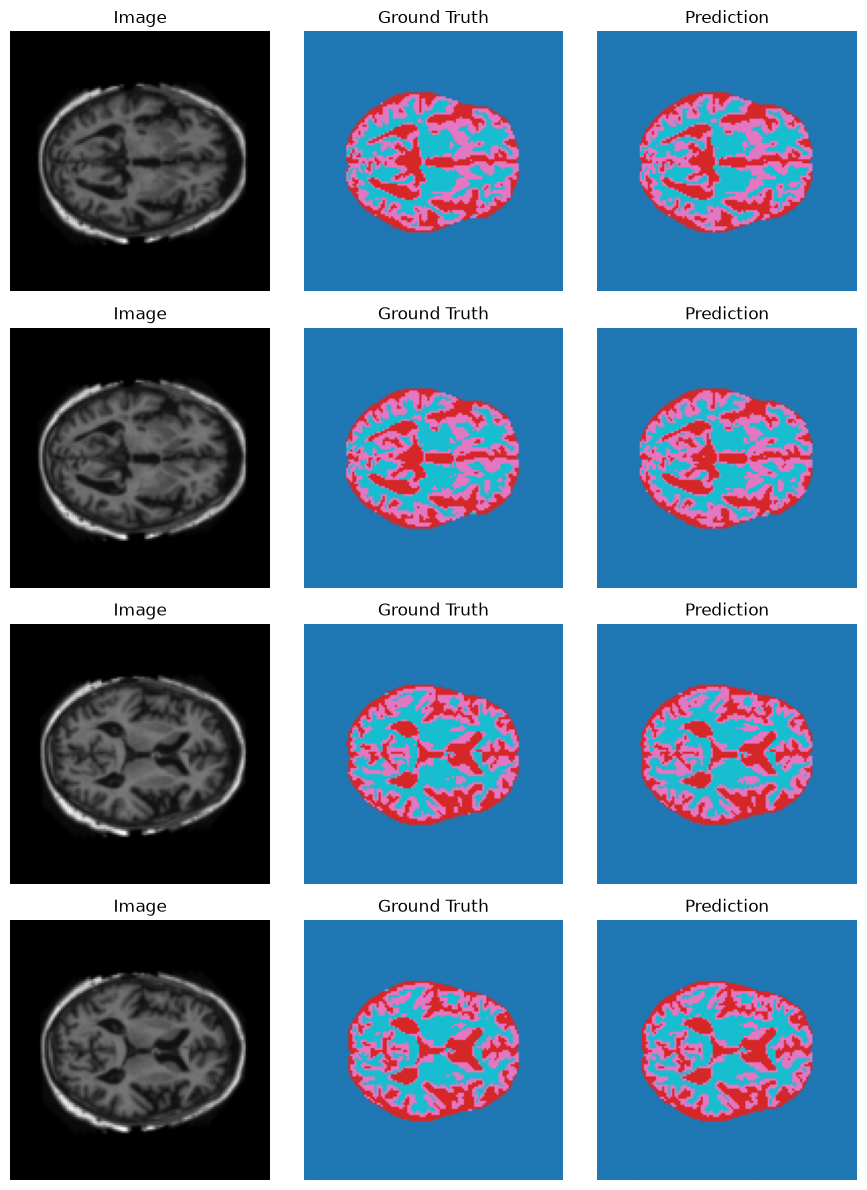

In [85]:
# Standalone demo cell - deliberately does not rely on `unet`, `device`,
# `class_names`, etc. still being set from the training loop above, so it
# can be run on its own at a live demo (after just the setup cells:
# imports, dataset/loaders, model classes, dice_score).
demo_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
demo_class_names = ["Background", "CSF", "Gray Matter", "White Matter"]

demo_unet = UNet(in_channels=1, num_classes=NUM_CLASSES).to(demo_device)
demo_unet.load_state_dict(torch.load("unet_best.pth", map_location=demo_device))
demo_unet.eval()

# Real test-set images, never used in training.
test_images, test_masks = next(iter(test_seg_loader))
test_images = test_images.to(demo_device)
test_masks = test_masks.to(demo_device)

with torch.no_grad():
    test_outputs = demo_unet(test_images)

dsc = dice_score(test_outputs, test_masks, num_classes=NUM_CLASSES)
for name, score in zip(demo_class_names, dsc):
    print(f"{name}: {score:.2f}")

pred_masks = torch.argmax(test_outputs, dim=1)

n = 4
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))

for i in range(n):
    axes[i, 0].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[i, 0].set_title("Image")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(test_masks[i].cpu(), cmap='tab10', vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_masks[i].cpu(), cmap='tab10', vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()